In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import (
    Input,
    Concatenate,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

In [2]:
resnet_model = load_model("resnet50_final.keras")
efficientnet_model = load_model("efficientnetb3_final.keras")

print("Both models loaded successfully!")

Both models loaded successfully!


In [3]:
resnet_feature_extractor = Model(
    inputs=resnet_model.input,
    outputs=resnet_model.layers[-2].output
)

efficientnet_feature_extractor = Model(
    inputs=efficientnet_model.input,
    outputs=efficientnet_model.layers[-2].output
)

print("ResNet Feature Shape:", resnet_feature_extractor.output_shape)
print("EfficientNet Feature Shape:", efficientnet_feature_extractor.output_shape)

ResNet Feature Shape: (None, 256)
EfficientNet Feature Shape: (None, 256)


In [4]:
resnet_feature_extractor.trainable = False
efficientnet_feature_extractor.trainable = False

In [5]:
from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# Input
input_layer = Input(shape=(224, 224, 3))

# Extract Features
resnet_features = resnet_feature_extractor(input_layer)
efficientnet_features = efficientnet_feature_extractor(input_layer)

# Combine Features
merged = Concatenate()([resnet_features, efficientnet_features])

# Classification Head
x = BatchNormalization()(merged)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(7, activation="softmax")(x)

# Final Hybrid Model
hybrid_model = Model(inputs=input_layer, outputs=output)

# Model Summary
hybrid_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 256)       │ 24,112,256 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 256)       │ 11,177,007 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ functional_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7)         │        903 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,456,438 (135.26 MB)

 Trainable params: 166,151 (649.03 KB)

 Non-trainable params: 35,290,287 (134.62 MB)

In [6]:
from tensorflow.keras.optimizers import Adam

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Hybrid model compiled successfully!")

Hybrid model compiled successfully!


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    )
]

In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\train"
val_dir   = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\val"
test_dir  = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\test"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 1811 files belonging to 7 classes.
Found 362 files belonging to 7 classes.
Found 365 files belonging to 7 classes.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
history = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.2297 - loss: 2.2054 - val_accuracy: 0.7265 - val_loss: 1.1682 - learning_rate: 1.0000e-04
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.4401 - loss: 1.5154 - val_accuracy: 0.8398 - val_loss: 0.7278 - learning_rate: 1.0000e-04
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.5975 - loss: 1.1138 - val_accuracy: 0.8536 - val_loss: 0.5312 - learning_rate: 1.0000e-04
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.6665 - loss: 0.9371 - val_accuracy: 0.8867 - val_loss: 0.4263 - learning_rate: 1.0000e-04
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.7223 - loss: 0.8040 - val_accuracy: 0.8950 - val_loss: 0.3657 - learning_rate: 1.0000e-04
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.7615 - loss: 0.6748 - val_accuracy: 0.8978 - val_loss: 0.3298 - learning_rate: 1.0000e-04
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.7841 

In [11]:
test_loss, test_accuracy = hybrid_model.evaluate(test_ds)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9288 - loss: 0.1856
Test Loss     : 0.1856192648410797
Test Accuracy : 0.9287671446800232


In [19]:
test_loss, test_accuracy = hybrid_model.evaluate(test_ds)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.9397 - loss: 0.1600
Test Loss     : 0.160007044672966
Test Accuracy : 0.9397260546684265


In [20]:
history = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.9183 - loss: 0.2505 - val_accuracy: 0.9475 - val_loss: 0.1797 - learning_rate: 4.0000e-06
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.9034 - loss: 0.2608 - val_accuracy: 0.9475 - val_loss: 0.1800 - learning_rate: 4.0000e-06
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9085 - loss: 0.2575
Epoch 3: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.
57/57 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.8995 - loss: 0.2739 - val_accuracy: 0.9475 - val_loss: 0.1802 - learning_rate: 4.0000e-06
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 181s 3s/step - accuracy: 0.9072 - loss: 0.2597 - val_accuracy: 0.9475 - val_loss: 0.1802 - learning_rate: 8.0000e-07
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.9039 - loss: 0.2628 - val_accuracy: 0.9475 - val_loss: 0.1797 - learning_rate: 8.0000e-07


12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step
HYBRID EFFICIENTNET + RESNET
Test Accuracy: 92.60%


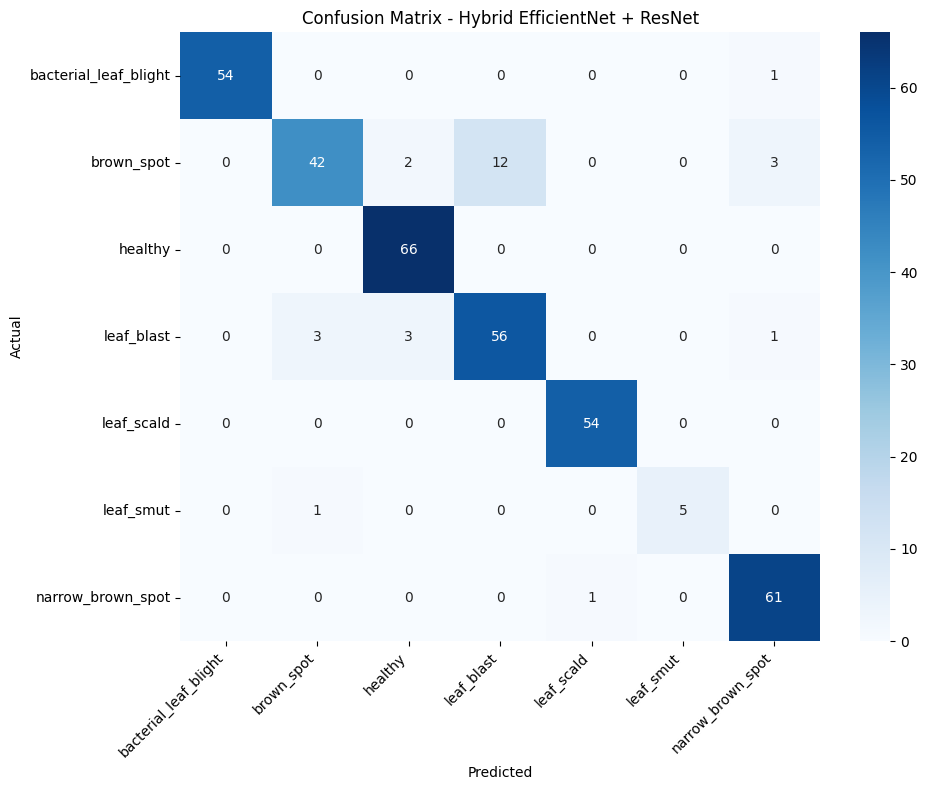


Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      0.98      0.99        55
           brown_spot       0.91      0.71      0.80        59
              healthy       0.93      1.00      0.96        66
           leaf_blast       0.82      0.89      0.85        63
           leaf_scald       0.98      1.00      0.99        54
            leaf_smut       1.00      0.83      0.91         6
    narrow_brown_spot       0.92      0.98      0.95        62

             accuracy                           0.93       365
            macro avg       0.94      0.91      0.92       365
         weighted avg       0.93      0.93      0.92       365


Verification:
Total test samples: 365
Correct predictions: 338
Accuracy from confusion matrix: 92.60%


In [16]:
# ==========================================
# HYBRID EFFICIENTNET + RESNET EVALUATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict
y_pred_prob = hybrid_model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# Convert one-hot labels to class numbers
if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)

# Class names
class_names = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "leaf_smut",
    "narrow_brown_spot"
]

# ==========================================
# ACCURACY
# ==========================================

accuracy = np.mean(y_true == y_pred)

print("=" * 60)
print("HYBRID EFFICIENTNET + RESNET")
print("=" * 60)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid EfficientNet + ResNet")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2
    )
)

# ==========================================
# VERIFICATION
# ==========================================

print("\nVerification:")
print("Total test samples:", cm.sum())
print("Correct predictions:", np.trace(cm))
print(
    "Accuracy from confusion matrix:",
    f"{np.trace(cm) / cm.sum() * 100:.2f}%"
)

In [17]:
# Save the trained Hybrid EfficientNet + ResNet model
hybrid_model.save(
    "Hybrid_EfficientNet_ResNet.keras"
)

print("Model saved successfully!")

Model saved successfully!
